In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from scripts.predictor import Predictor

Importing plotly failed. Interactive plots will not work.


# Loading Data

In [3]:
df = pd.read_csv("../../data_processed/SG_nona.csv", parse_dates=["date"])

df

,date,new_confirmed,new_deceased,new_tested,cumulative_confirmed,cumulative_deceased,new_persons_vaccinated,cumulative_persons_vaccinated,new_persons_fully_vaccinated,cumulative_persons_fully_vaccinated,...,search_trends_wheeze,search_trends_xeroderma,search_trends_xerostomia,search_trends_yawn,average_temperature_celsius,minimum_temperature_celsius,maximum_temperature_celsius,rainfall_mm,dew_point,relative_humidity
0,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.30,4.45,0.46,0.25,27.816667,25.400000,31.444444,0.406400,23.622222,78.160465
1,2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.31,4.33,0.44,0.19,27.483333,25.116667,30.522222,1.213556,24.072222,81.775103
2,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,4.40,0.40,0.21,27.627778,25.266667,31.172222,0.793750,24.255556,82.004853
3,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.29,4.78,0.42,0.21,27.200000,24.700000,30.883333,1.682750,23.800000,81.865993
4,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,4.44,0.41,0.24,27.744444,24.811111,31.872222,0.431800,23.477778,77.721261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2022-09-13,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
987,2022-09-14,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
988,2022-09-15,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
989,2022-09-16,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906


# Running Predictor

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.axes import Axes

In [36]:
def plot_scatter_on_ax(ax: Axes, df: pd.DataFrame, var_col: str, alg_type: str|None = None, plot_num: int = 0) -> None:
    if alg_type is not None:
        ax.scatter(df["date"], df[f"{var_col}_{"yhat"}"], label = f"{alg_type}-{var_col}", s = 1, marker = ".", color = f"C{plot_num}")
    else:
        ax.scatter(df["date"], df[f"{var_col}"], label = f"{var_col}", s = 1, marker = ".", color = f"C{plot_num}")
        

def configure_axis(ax: Axes, df_before: pd.DataFrame) -> None:
    ax.axhline(0, color = "black", ls = "-", lw = 0.5)
    ax.axvline(df_before["date"].min(), color = "black", ls = "-", lw = 0.5)

    ax.axvline(df_before.iloc[-1]["date"], ls = "--", color = f"C{1}", lw = 1, label = "Prediction Starting")


    ax.tick_params(axis='x', labelrotation=-45, labelsize = 7)
    ax.tick_params(axis='y', labelrotation=-45, labelsize = 7)

    ax.legend(fontsize=9)
    ax.grid(True)

In [37]:
def plot_multiple_data(df: pd.DataFrame, forecast: dict[str, pd.DataFrame], columns: list[str]) -> None:
    fig, axs = plt.subplots(len(columns), figsize = (12, 4 * len(columns)))




    for i, (ax, col) in enumerate(zip(axs, columns)):
        plot_scatter_on_ax(ax, forecast['prophet'], col, "prophet", 0)
        plot_scatter_on_ax(ax, forecast["arima"], col, "arima", 1)

        plot_scatter_on_ax(ax, df, col, None, 3)


    for ax in axs:
        configure_axis(ax=ax, df_before=df)

In [29]:
date_min, date_max, date_pred = len(df)//4, len(df)//2, len(df)//4

In [30]:
predictor = Predictor(df, date_min, date_max, date_pred)

In [31]:
predictor.fit(["new_confirmed", "search_trends_shyness"])

17:09:10 - cmdstanpy - INFO - Chain [1] start processing
17:09:10 - cmdstanpy - INFO - Chain [1] done processing


[Prophet] Fitting column: new_confirmed
[ARIMA]   Fitting column: new_confirmed


17:09:12 - cmdstanpy - INFO - Chain [1] start processing
17:09:12 - cmdstanpy - INFO - Chain [1] done processing


[Prophet] Fitting column: search_trends_shyness
[ARIMA]   Fitting column: search_trends_shyness
[OK] Fitting complete.


In [32]:
forecast = predictor.get_forecast()

In [33]:
forecast["prophet"]

,date,new_confirmed_yhat,new_confirmed_yhat_lower,new_confirmed_yhat_upper,search_trends_shyness_yhat,search_trends_shyness_yhat_lower,search_trends_shyness_yhat_upper
0,2021-05-11,17.756164,0.0,43.540448,0.665285,0.565037,0.762318
1,2021-05-12,17.421002,0.0,42.896614,0.652428,0.557652,0.753978
2,2021-05-13,17.085695,0.0,41.256069,0.655030,0.560041,0.755365
3,2021-05-14,17.001922,0.0,42.595554,0.648659,0.547663,0.753193
4,2021-05-15,17.508046,0.0,42.790989,0.663980,0.567242,0.764703
...,...,...,...,...,...,...,...
242,2022-01-08,15.275057,0.0,39.826987,0.645942,0.550160,0.744077
243,2022-01-09,12.452309,0.0,37.599450,0.614539,0.514336,0.711825
244,2022-01-10,12.348931,0.0,39.297919,0.629020,0.526547,0.728281
245,2022-01-11,15.456905,0.0,39.768353,0.646719,0.548781,0.741540


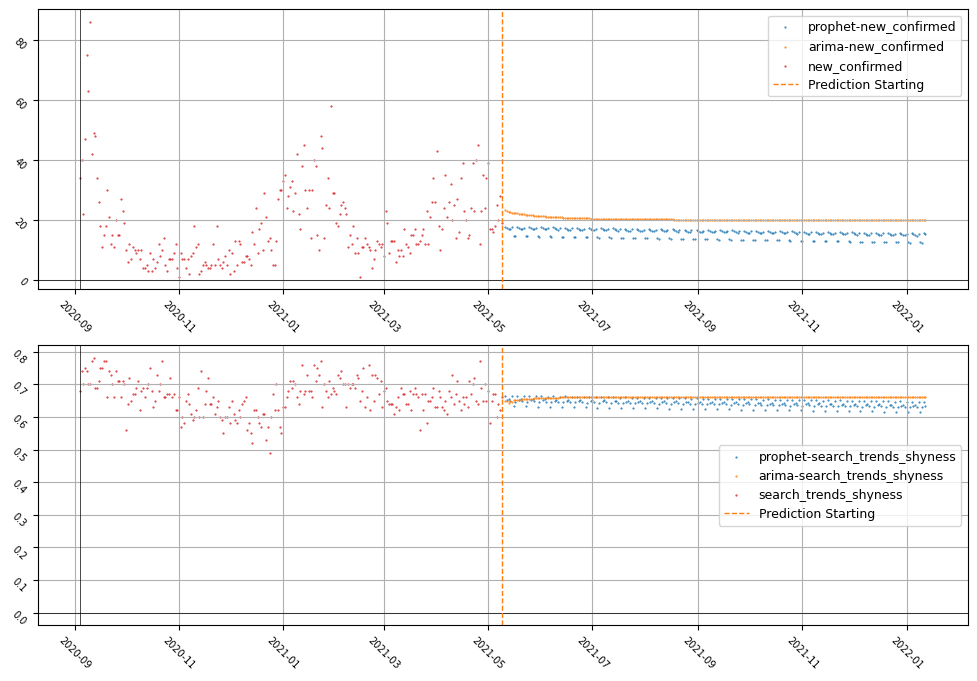

In [38]:
plot_multiple_data(df.iloc[date_min:date_max], forecast, ["new_confirmed", "search_trends_shyness"])